# 🤖 Notebook 2: Entrenamiento del Modelo

Este notebook cubre:
- Carga de datos con DataLoaders
- Creación del modelo con Transfer Learning (MobileNetV2)
- Configuración del entrenamiento
- Entrenamiento con early stopping
- Guardado del modelo

In [12]:
# Imports
import sys
sys.path.append('..')

import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from src.dataset.dataset import create_dataloaders
from src.models.classifier import create_model
from src.models.train import train_model, EarlyStopping
from src.utils.helpers import load_config, plot_training_history

# Configuración
plt.rcParams['figure.figsize'] = (15, 5)

## 1. Configuración

In [13]:
# Cargar configuración
config = load_config('../config/config.yaml')

# Parámetros
BATCH_SIZE = config['training']['batch_size']
EPOCHS = config['training']['epochs']
LEARNING_RATE = config['training']['learning_rate']
IMAGE_SIZE = config['dataset']['image_size']
ARCHITECTURE = config['model']['architecture']

# Dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo: {device}")
print(f"PyTorch version: {torch.__version__}")

Dispositivo: cpu
PyTorch version: 2.9.1+cpu


## 2. Carga de Datos

In [14]:
# Crear DataLoaders
train_loader, val_loader, test_loader, class_names = create_dataloaders(
    train_dir='../data/processed/train',
    val_dir='../data/processed/val',
    test_dir='../data/processed/test',
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    num_workers=2,  # Ajustar según tu CPU
    augment=True
)

num_classes = len(class_names)
print(f"\nClases ({num_classes}):")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")


DataLoaders creados:
Train: 13339 imágenes (417 batches)
Val:   3025 imágenes (95 batches)
Test:  3182 imágenes (100 batches)
Batch size: 32
Clases: 99


Clases (99):
  0: Aloevera
  1: Amla
  2: Amruthaballi
  3: Arali
  4: Arive Dantu
  5: Arjun
  6: Astma_weed
  7: Badipala
  8: Balloon_Vine
  9: Bamboo
  10: Basale
  11: Beans
  12: Betel
  13: Bhrami
  14: Bringaraja
  15: Caricature
  16: Castor
  17: Catharanthus
  18: Chakte
  19: Chilly
  20: Citron lime (herelikai)
  21: Coffee
  22: Common rue(naagdalli)
  23: Coriender
  24: Curry
  25: Doddpathre
  26: Drumstick
  27: Ekka
  28: Eucalyptus
  29: Fenugreek
  30: Ganigale
  31: Ganike
  32: Gasagase
  33: Ginger
  34: Globe Amarnath
  35: Guava
  36: Henna
  37: Hibiscus
  38: Honge
  39: Indian Beech
  40: Indian Mustard
  41: Insulin
  42: Jackfruit
  43: Jamaica Cherry Gasagase
  44: Jamun
  45: Jasmine
  46: Kambajala
  47: Karanda
  48: Kasambruga
  49: Kohlrabi
  50: Lantana
  51: Lemon
  52: Lemongrass
  53: Malabar_

## 3. Visualización de Datos Aumentados

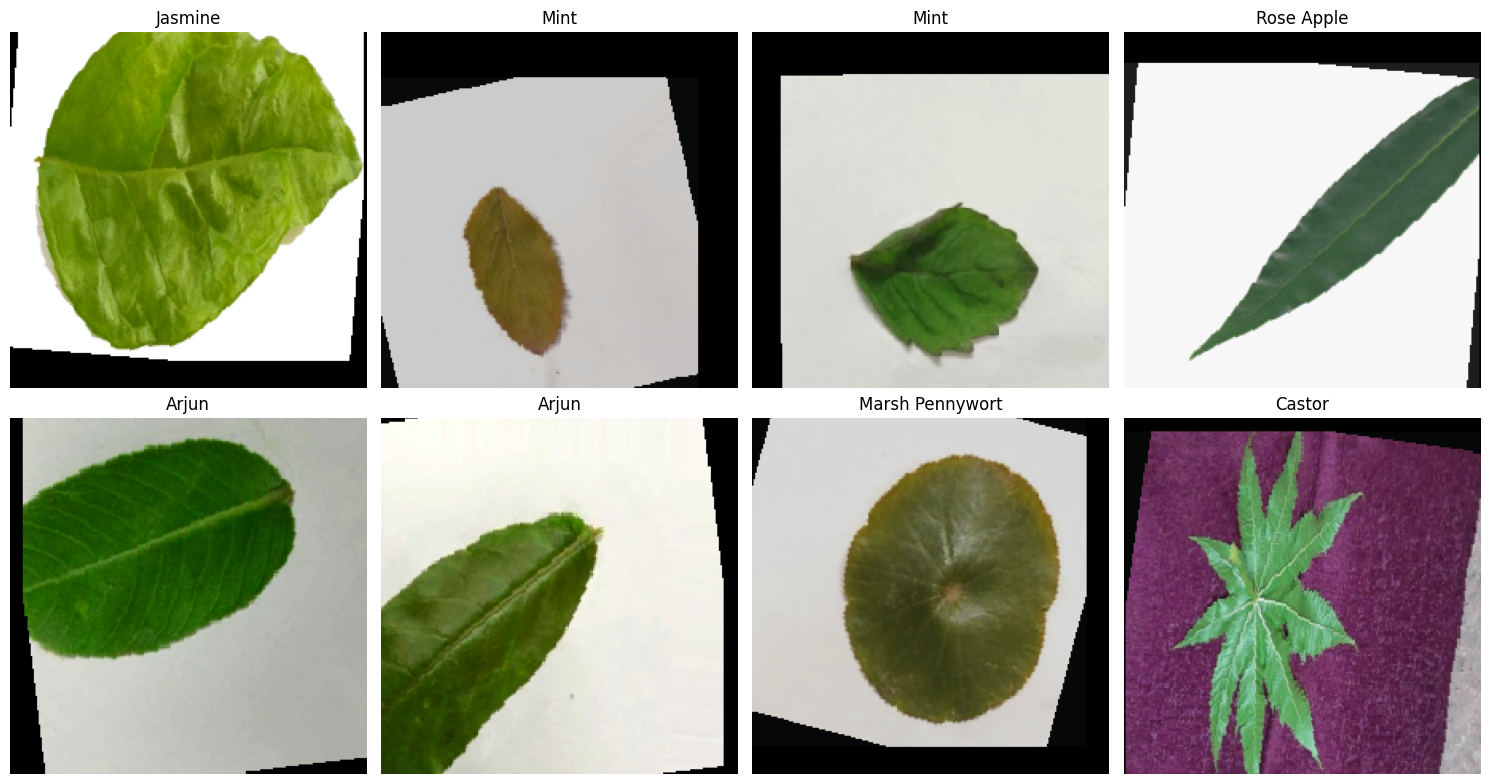

In [15]:
# Visualizar batch de entrenamiento
import torchvision
import numpy as np

def imshow(img, title=None):
    """Muestra una imagen de tensor."""
    # Desnormalizar
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Obtener un batch
images, labels = next(iter(train_loader))

# Mostrar grid
fig = plt.figure(figsize=(15, 8))
for i in range(min(8, len(images))):
    ax = plt.subplot(2, 4, i + 1)
    imshow(images[i], title=class_names[labels[i]])

plt.tight_layout()
plt.show()

## 4. Creación del Modelo

In [16]:
# Crear modelo
model = create_model(
    num_classes=num_classes,
    architecture=ARCHITECTURE,
    pretrained=True,
    dropout=config['model']['dropout'],
    freeze_ratio=config['model']['freeze_ratio'],
    device=device
)


Creando modelo mobilenet_v2...
✓ Congeladas 110/158 capas (70.0%)

Resumen del Modelo: mobilenet_v2
Arquitectura base: mobilenet_v2
Número de clases: 99
Parámetros totales: 2,350,691
Parámetros entrenables: 1,870,563
Parámetros congelados: 480,128



## 5. Configuración del Entrenamiento

In [17]:
# Función de pérdida
criterion = nn.CrossEntropyLoss()

# Optimizador
if config['training']['optimizer'] == 'adam':
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
else:
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

# Learning rate scheduler
if config['training']['scheduler'] == 'step':
    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=config['training']['step_size'],
        gamma=config['training']['gamma']
    )
else:
    scheduler = None

# Early stopping
early_stopping = None
if config['training']['early_stopping']['enabled']:
    early_stopping = EarlyStopping(
        patience=config['training']['early_stopping']['patience'],
        mode='min'
    )

print("Configuración de entrenamiento:")
print(f"  - Función de pérdida: CrossEntropyLoss")
print(f"  - Optimizador: {config['training']['optimizer']}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Scheduler: {config['training']['scheduler']}")
print(f"  - Early stopping: {config['training']['early_stopping']['enabled']}")

Configuración de entrenamiento:
  - Función de pérdida: CrossEntropyLoss
  - Optimizador: adam
  - Learning rate: 0.001
  - Scheduler: step
  - Early stopping: True


## 6. Entrenamiento

In [18]:
# Entrenar modelo
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=EPOCHS,
    device=device,
    scheduler=scheduler,
    early_stopping=early_stopping,
    checkpoint_dir='../models/checkpoints',
    class_names=class_names
)


Iniciando entrenamiento
Épocas: 50
Dispositivo: cpu
Learning rate: 0.001
Batch size: 32


Época [1/50]
----------------------------------------------------------------------


Train Loss: 1.4810 | Train Acc: 63.53%
Val Loss:   0.8252 | Val Acc:   76.93%
LR: 0.001000 | Tiempo: 314.8s
✓ Mejor modelo guardado (Val Acc: 76.93%)

Época [2/50]
----------------------------------------------------------------------


Train Loss: 0.6419 | Train Acc: 81.71%
Val Loss:   0.3903 | Val Acc:   88.40%
LR: 0.001000 | Tiempo: 244.1s
✓ Mejor modelo guardado (Val Acc: 88.40%)

Época [3/50]
----------------------------------------------------------------------


Train Loss: 0.4429 | Train Acc: 87.00%
Val Loss:   0.3366 | Val Acc:   90.18%
LR: 0.001000 | Tiempo: 245.2s
✓ Mejor modelo guardado (Val Acc: 90.18%)

Época [4/50]
----------------------------------------------------------------------


Train Loss: 0.3497 | Train Acc: 89.59%
Val Loss:   0.2933 | Val Acc:   91.40%
LR: 0.001000 | Tiempo: 244.4s
✓ Mejor modelo guardado (Val Acc: 91.40%)

Época [5/50]
----------------------------------------------------------------------


...

Train Loss: 0.0224 | Train Acc: 99.39%
Val Loss:   0.0563 | Val Acc:   98.28%
LR: 0.000000 | Tiempo: 235.5s

Época [44/50]
----------------------------------------------------------------------


Train Loss: 0.0202 | Train Acc: 99.42%
Val Loss:   0.0562 | Val Acc:   98.41%
LR: 0.000000 | Tiempo: 231.3s

Época [45/50]
----------------------------------------------------------------------


Train Loss: 0.0191 | Train Acc: 99.48%
Val Loss:   0.0559 | Val Acc:   98.38%
LR: 0.000000 | Tiempo: 232.5s

Época [46/50]
----------------------------------------------------------------------


Train Loss: 0.0208 | Train Acc: 99.39%
Val Loss:   0.0531 | Val Acc:   98.51%
LR: 0.000000 | Tiempo: 232.7s
✓ Mejor modelo guardado (Val Acc: 98.51%)

Época [47/50]
----------------------------------------------------------------------


Train Loss: 0.0208 | Train Acc: 99.44%
Val Loss:   0.0562 | Val Acc:   98.38%
LR: 0.000000 | Tiempo: 232.9s

⚠ Early stopping activado en época 47

Entrenamiento completado
Tiempo total: 3h 5m 44s
Mejor Val Acc: 98.51% (Época 46)



## 7. Visualización del Entrenamiento

Gráfica de entrenamiento guardada en: ../docs/training_history.png


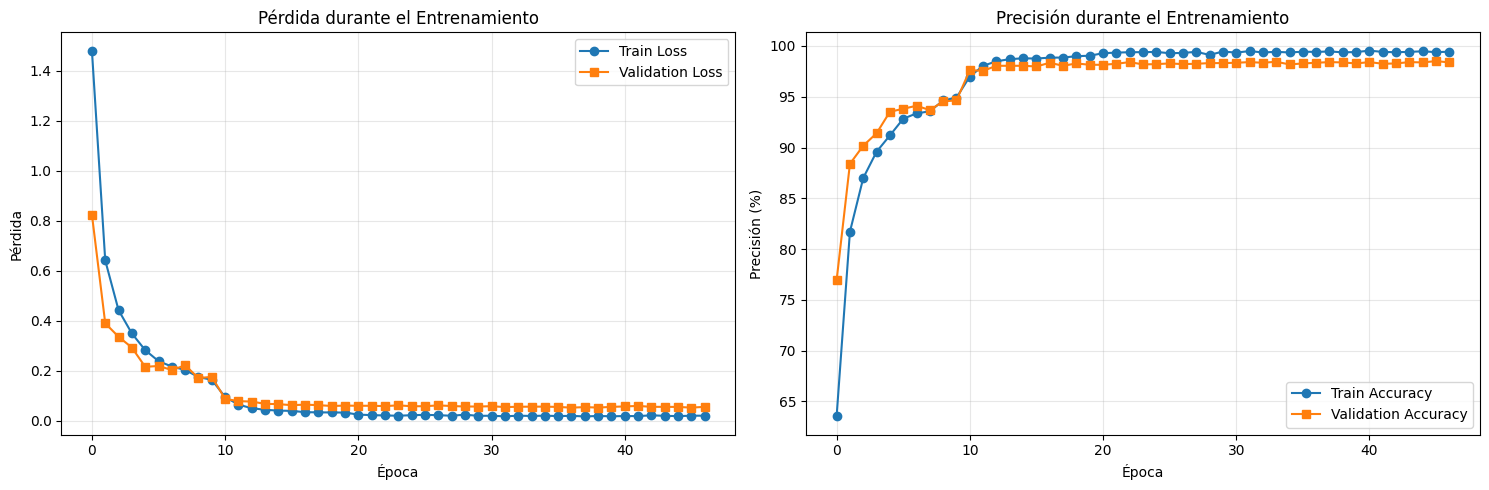

In [19]:
# Graficar historial de entrenamiento
plot_training_history(history, save_path='../docs/training_history.png')

## 8. Guardar Modelo Final

In [20]:
# Copiar el mejor modelo a la ubicación final
import shutil

best_model_path = '../models/checkpoints/best_model.pth'
final_model_path = '../models/best_model.pth'

if os.path.exists(best_model_path):
    shutil.copy(best_model_path, final_model_path)
    print(f"✓ Modelo guardado en: {final_model_path}")
else:
    print("⚠ No se encontró el mejor modelo")

✓ Modelo guardado en: ../models/best_model.pth


## 9. Resumen del Entrenamiento

In [21]:
# Mostrar resumen
print("\n" + "="*70)
print("RESUMEN DEL ENTRENAMIENTO")
print("="*70)
print(f"Arquitectura: {ARCHITECTURE}")
print(f"Número de clases: {num_classes}")
print(f"Épocas entrenadas: {len(history['train_loss'])}")
print(f"Mejor Train Acc: {max(history['train_acc']):.2f}%")
print(f"Mejor Val Acc: {max(history['val_acc']):.2f}%")
print(f"Mejor Train Loss: {min(history['train_loss']):.4f}")
print(f"Mejor Val Loss: {min(history['val_loss']):.4f}")
print("="*70)


RESUMEN DEL ENTRENAMIENTO
Arquitectura: mobilenet_v2
Número de clases: 99
Épocas entrenadas: 47
Mejor Train Acc: 99.54%
Mejor Val Acc: 98.51%
Mejor Train Loss: 0.0178
Mejor Val Loss: 0.0530


## 10. Próximos Pasos

1. ✅ Modelo entrenado y guardado
2. ➡️ Continuar con `03_evaluacion_modelo.ipynb` para evaluar en el conjunto de test
3. ➡️ Probar el modelo en la aplicación Flask

In [22]:
print("\n✓ Entrenamiento completado")
print("\nPróximo paso: Abrir 03_evaluacion_modelo.ipynb")


✓ Entrenamiento completado

Próximo paso: Abrir 03_evaluacion_modelo.ipynb
